# 8. Exploitation des données désambiguïsées

Au chapitre 7, vous avez relié des formes de surface à des entités stables (`@key`) et à votre base SQLite. Ce chapitre montre **pourquoi** ce travail compte : d'abord en vérifiant que rien n'a « fuité » (mentions balisées mais pas désambiguïsées), puis en produisant des tableaux et graphiques impossibles à obtenir en comptant seulement des chaînes de caractères.

Comme au chapitre 6, tout s'exécute dans cette page JupyterLite. Téléversez votre transcription XML balisée et votre base SQLite ci-dessous.

**Base locale et base centrale.** La base SQLite locale accompagne votre projet et peut être sauvegardée, copiée et transportée avec lui. La base centrale de LJB est partagée entre plusieurs projets ou utilisateurs et sert de source commune ; elle ne doit donc pas être traitée comme un simple fichier de travail. Les identifiants et les décisions synchronisés entre les deux peuvent nécessiter une résolution de conflits.

Les résultats doivent toujours pouvoir être **ramenés aux passages sources** dans l'éditeur : ce sont des outils de contrôle et d'argumentation, pas une vérité automatique.

Exécutez la cellule suivante, puis choisissez d'abord le XML balisé et ensuite la base SQLite avec les deux boutons qui apparaissent.


In [1]:
%pip install -q ipywidgets lxml pandas matplotlib

from pathlib import Path
import sys

scripts_dir = next(
    candidate
    for candidate in (Path("scripts"), Path("../scripts"), Path("../../scripts"), Path("../../../scripts"))
    if candidate.exists()
)
sys.path.insert(0, str(scripts_dir.resolve()))

import importlib
import xml_upload
importlib.reload(xml_upload)
from xml_upload import show_entity_db_upload, show_upload

show_upload()
show_entity_db_upload()



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import sys

scripts_dir = next(
    candidate
    for candidate in (Path("scripts"), Path("../scripts"), Path("../../scripts"), Path("../../../scripts"))
    if candidate.exists()
)
sys.path.insert(0, str(scripts_dir.resolve()))

import importlib
import chapter_08_analyses
importlib.reload(chapter_08_analyses)
from chapter_08_analyses import resolve_entities_path, setup_scripts_path
from xml_upload import get_xml_path

setup_scripts_path()

XML_PATH = get_xml_path()
ENTITY_DB_PATH = resolve_entities_path(XML_PATH)

print(f"Texte : {XML_PATH}")
print(f"Base SQLite : {ENTITY_DB_PATH or '(non trouvée — certaines sections seront ignorées)'}")


Texte : ../../../data/NanQiShu_bio_130_j_42_JiangShi.xml
Base SQLite : ../../../data/entities.sqlite


## Exemple 1 : Contrôle des fuites (« leakage »)

Avant toute statistique, vérifiez la **couverture** de la désambiguïsation : pour chaque type de balise (`persName`, `placeName`, …), combien de mentions ont un `@key` et combien n'en ont pas ?

Objectif : un tableau de bord honnête. S'il reste des mentions sans clé, vos graphiques suivants ne représentent qu'une **partie** du texte.


In [3]:
from IPython.display import display

from chapter_08_analyses import leakage_inconsistent_surfaces, leakage_summary

display(leakage_summary(XML_PATH))

inconsistent = leakage_inconsistent_surfaces(XML_PATH)
if inconsistent.empty:
    print("Aucune forme à la fois avec et sans @key.")
else:
    print("Formes à corriger (même chaîne, parfois désambiguïsée, parfois non) :")
    display(inconsistent)


,tag,avec_key,total,sans_key,pct_key
1,placeName,1,28,27,3.6
2,title,0,9,9,0.0
0,persName,89,91,2,97.8


Aucune forme à la fois avec et sans @key.


## Exemple 2 : Avant / après désambiguïsation

Comparez le **top des chaînes** (`persName` bruts) au **top des personnages** (regroupés par `@key`). La colonne `canonical_name` vient de la base SQLite et rend le second tableau lisible. Sans clé, les homonymes et les variantes (nom complet vs prénom seul) faussent le classement.


In [4]:
from IPython.display import display

import importlib
import chapter_08_analyses
importlib.reload(chapter_08_analyses)
from chapter_08_analyses import before_after_top_names

by_surface, by_key = before_after_top_names(XML_PATH, ENTITY_DB_PATH)

print("Top des formes de surface (persName)")
display(by_surface)

print("Top des personnages (par @key)")
display(by_key)


Top des formes de surface (persName)


,surface_form,mentions
0,祏,29
1,暄,9
2,高宗,8
3,遙光,6
4,劉暄,5
5,寶玄,5
6,祀,4
7,德隣,3
8,江祏,2
9,遵,2


Top des personnages (par @key)


,key,mentions
0,person-29f670ff-f416-47a6-a7c7-004ae48ca49e,32
1,person-77e8c5e6-0f0b-49ad-ba6c-59f5c0538335,14
2,person-00c13efd-2333-4d6f-851a-d0d19ad5fe01,8
3,person-d0b0cce5-8f74-43ad-9450-698ec8140f36,6
4,person-9196c5f3-2eee-4f1d-9118-178a2952a9da,5
5,person-b38fdc14-a6ed-418e-851f-04ce89609df8,4
6,person-bb4c463d-c235-4444-bf04-780ab51e7e64,3
7,person-3348643f-dacf-40e6-be84-91d7999d31e6,2
8,person-aec3ae44-4ae6-445f-94de-d934ad90b363,2
9,person-68720a7a-a0dd-4b0b-b9d2-129fb76adc90,2


## Exemple 3 : Personnages dans la base et dans le texte

On croise la **base SQLite** (toutes les personnes que vous avez préparées) avec les mentions **@key** du texte. La colonne `formes_dans_le_texte` liste chaque variante et son effectif. Les lignes à **0 mention** ne sont pas une erreur : elles signalent des entités prêtes pour le projet mais absentes de ce fichier (ou pas encore citées).


In [5]:
from IPython.display import display

from chapter_08_analyses import person_registry_table

if ENTITY_DB_PATH is None:
    print("Ajoutez la base SQLite dans data/ pour afficher ce tableau.")
else:
    registry_df = person_registry_table(XML_PATH, ENTITY_DB_PATH, entity_type="person")
    display(registry_df)


,key,label,mentions,formes_dans_le_texte,birth_year,death_year,alt_names_db
0,person-29f670ff-f416-47a6-a7c7-004ae48ca49e,江祏,32,祏 (29); 江祏 (2); 弘業 (1),NaN,499.0,Jiang Shi; 弘業; 江; 祏
1,person-77e8c5e6-0f0b-49ad-ba6c-59f5c0538335,劉暄,14,暄 (9); 劉暄 (5),NaN,NaN,Liu Xuan; 劉; 暄
2,person-00c13efd-2333-4d6f-851a-d0d19ad5fe01,蕭鸞,8,高宗 (8),452.0,498.0,Xiao Luan; 高宗; 明皇帝; 蕭; 鸞; 景栖
3,person-d0b0cce5-8f74-43ad-9450-698ec8140f36,王遙光,6,遙光 (6),NaN,NaN,Wang Yaoguang; 王; 遙光
4,person-9196c5f3-2eee-4f1d-9118-178a2952a9da,蕭寶玄,5,寶玄 (5),NaN,NaN,寶玄; 智深; 蕭; Xiao Baoxuan
...,...,...,...,...,...,...,...
413,person-62324dbb-9b4b-4194-a75f-f250038bc812,鮮于文粲,0,,NaN,NaN,Xianyu Wencan; 鮮于; 文粲
414,person-4e1a6e6e-2dd3-4950-9289-25c8dc614d63,黃回,0,,427.0,478.0,Huang Hui; 黃; 回
415,person-f7e1c17b-af20-4ef3-b28c-bcb9f518a6e3,黃文濟,0,,NaN,NaN,Huang Wenji; 黃; 文濟
416,person-33a437d5-c0da-445e-8796-3bfc67b01b17,齊始安貞王蕭道生,0,,NaN,NaN,Qi Shianzhenwangxiaodaosheng; 蕭道生; 道生; 蕭孝伯; 齊;...


## Exemple 4 : Personnages dans le temps

Pour chaque personne dans la **base SQLite**, on calcule une **position biographique** : la moyenne des années de naissance et de décès lorsque les deux sont connues, sinon l'unique date disponible. L'axe horizontal du graphique regroupe ainsi les personnages dans le temps ; l'axe vertical compte leurs mentions désambiguïsées dans **votre** texte.

La **ligne verticale** indique la date du document, lue dans les métadonnées TEI (`teiHeader`, balises `<date when="…">`). Elle permet de situer d'un coup d'œil si le texte traite surtout de contemporains, d'ancêtres, etc. Si aucune date n'est trouvée dans l'en-tête, le graphique s'affiche sans cette ligne — vérifiez alors le balisage des métadonnées dans l'éditeur.


,label,birth_year,death_year,mean_life_year,mentions
0,曾參,-504.0,-435.0,-469.5,0
1,韓浩,25.0,218.0,121.5,0
2,馬融,79.0,166.0,122.5,0
3,鄭玄,127.0,200.0,163.5,0
4,曹操,155.0,220.0,187.5,0
...,...,...,...,...,...
413,高璉,NaN,NaN,NaN,0
414,鮮于文粲,NaN,NaN,NaN,0
415,黃文濟,NaN,NaN,NaN,0
416,齊始安貞王蕭道生,NaN,NaN,NaN,0


Date du texte (métadonnées) : 537


/Users/daniel/Code/leJeanBaptiste/Workshop/scripts/chapter_08_analyses.py:378: UserWarning: Glyph 26366 (\N{CJK UNIFIED IDEOGRAPH-66FE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/Users/daniel/Code/leJeanBaptiste/Workshop/scripts/chapter_08_analyses.py:378: UserWarning: Glyph 21443 (\N{CJK UNIFIED IDEOGRAPH-53C3}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/Users/daniel/Code/leJeanBaptiste/Workshop/scripts/chapter_08_analyses.py:378: UserWarning: Glyph 38867 (\N{CJK UNIFIED IDEOGRAPH-97D3}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/Users/daniel/Code/leJeanBaptiste/Workshop/scripts/chapter_08_analyses.py:378: UserWarning: Glyph 28009 (\N{CJK UNIFIED IDEOGRAPH-6D69}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/Users/daniel/Code/leJeanBaptiste/Workshop/scripts/chapter_08_analyses.py:378: UserWarning: Glyph 39340 (\N{CJK UNIFIED IDEOGRAPH-99AC}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/Users/daniel/Code/leJeanBaptiste/Worksh

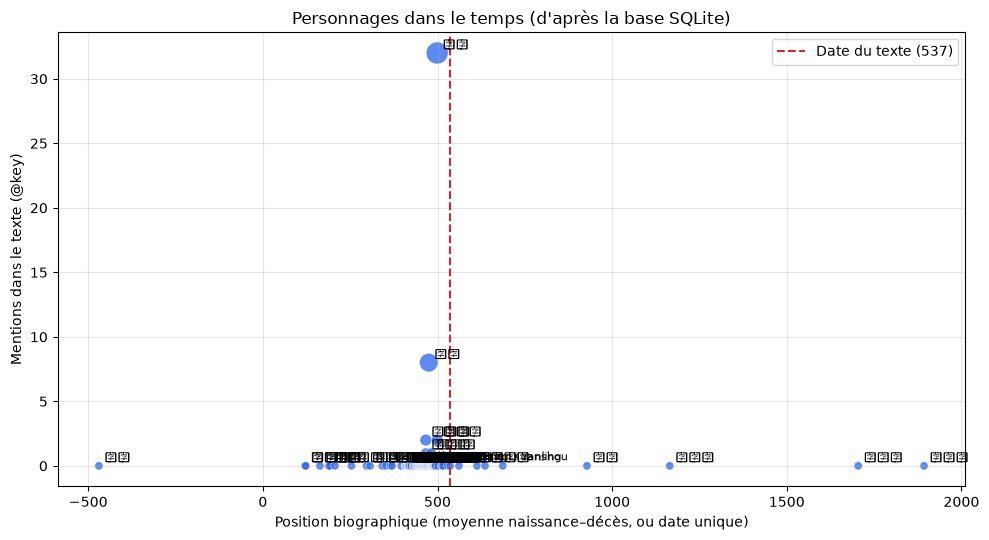

In [6]:
from IPython.display import display

import importlib
import chapter_08_analyses
importlib.reload(chapter_08_analyses)
from chapter_08_analyses import (
    person_life_timeline_table,
    plot_person_life_grouping,
    tei_document_year,
)

if ENTITY_DB_PATH is None:
    print("Ajoutez la base SQLite dans data/ pour cette analyse.")
else:
    life_df = person_life_timeline_table(XML_PATH, ENTITY_DB_PATH)
    display(life_df[["label", "birth_year", "death_year", "mean_life_year", "mentions"]])

    doc_year = tei_document_year(XML_PATH)
    if doc_year is None:
        print("Aucune date de document trouvée dans teiHeader — ligne verticale omise.")
    else:
        print(f"Date du texte (métadonnées) : {doc_year:g}")

    plot_person_life_grouping(life_df, document_year=doc_year)


## Prolongements

- **Lieux** : reprenez `person_registry_table(..., entity_type="place")` ; les coordonnées peuvent être exportées en KML pour Google Earth.
- **Site de lecture** : votre TEI + base SQLite suffisent pour générer une page HTML (plan du texte à gauche, liens `@ref` vers les autorités) — voir le chapitre 10 pour l'autonomie sur ce type de livrable.
- **Ligne de commande** : `python scripts/chapter_08_entities.py votre-texte.xml --entities entities.sqlite --output-dir outputs/chapter-08` exporte les CSV.

## Exercices

- [ ] Interpréter votre tableau de fuites : quel type de balise reste le moins désambiguïsé ?
- [ ] Propager `@key` pour une forme listée comme incohérente, puis relancer l'exemple 1.
- [ ] Expliquer une ligne à 0 mention dans le tableau registry (personnage absent ? autre volume ?).
- [ ] Comparer la ligne « date du texte » aux nuages de points : le corpus est-il cohérent chronologiquement ?
- [ ] Repérer un personnage loin du groupe principal : homonyme, mauvaise clé, ou intérêt historique réel ?
- [ ] Imaginer une colonne ou un filtre utile pour **votre** question de recherche (rôle, certitude `@cert`, dynastie, etc.).
